# Restatement Shock (Item 4.02) — a quantitative teardown 🔬
### Market-adjusted event study on EDGAR "do not rely" 8-Ks · month-clustered HAC inference · a chronic-decay paired placebo · horizon, era & penny-floor robustness · size split · borrow-aware shorting costs

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Small-cap story?: Mixed](https://img.shields.io/badge/Small--cap_story%3F-Mixed-8b949e?style=flat-square)

Deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim: the market **underreacts** to Item 4.02 non-reliance 8-Ks — the confession keeps hurting for months. The raw drift *screams*; the study's job is to ask whether it is **event-specific** — and the answer flips the verdict.

> ⚠️ **Deads-missing bias, named on the Signal axis.** Tickers come from the SEC's *current* CIK→ticker map and yfinance carries no delisted history: 65% of filings never reach the tape, and post-confession **bankruptcies drop out**. Every negative number below is an **understatement** of the true damage; the bias is worst for old events (visible in the era split).
>
> 💡 The `💡 In plain words` notes translate each block back to intuition. Numbers: [`docs/results.md`](../docs/results.md) (fingerprint `9b979967dc4c`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from restatement_shock import data, strategy as st

HAVE_REAL = data.have_real()
AS_OF = "2026-06-30"
if HAVE_REAL:
    EV, CLOSE, DVOL, SPY = data.load_real()
    SPY = SPY[SPY.index <= AS_OF]; CLOSE = CLOSE[CLOSE.index <= AS_OF]
    DVOL = DVOL[DVOL.index <= AS_OF]
    TAB = st.build_event_table(EV, CLOSE, DVOL, SPY)
else:
    EV = CLOSE = DVOL = SPY = TAB = None
print("real cache present:", HAVE_REAL,
      "| usable events:", (0 if TAB is None else len(TAB)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_fts': 1498, 'n_ticker': 520, 'n_usable': 359, 'start': '2004-09', 'end': '2026-06', 'ar0_mean': -2.32, 'ar0_median': -0.66, 'ar0_t': -3.17, 'ar0_t_wins': -4.55, 'ar0_t_hac': -2.27, 'car_mean': -15.84, 'car_median': -5.86, 'car_t': -4.01, 'car_t_wins': -5.06, 'car_t_hac': -4.41, 'n_months': 162, 'neg_share': 0.624, 'floors': [(1, 289, -13.41, -4.79, -4.2), (5, 228, -12.97, -4.05, -3.54)], 'n_pairs': 324, 'plc_event': -17.49, 'plc_event_t': -4.07, 'plc_plc': -13.13, 'plc_plc_t': -4.27, 'diff': -4.36, 'diff_t': -0.85, 'diff_t_wins': -0.93, 'diff_t_hac': -0.63, 'horizon': [(5, 367, -0.75, -0.92, -1.17), (21, 365, -6.27, -3.36, -2.7), (42, 361, -8.54, -2.79, -2.86), (63, 359, -15.84, -4.01, -4.41), (126, 352, -23.9, -5.37, -4.47)], 'era': [('2004-2012', 92, -0.4, -0.48, -2.81, -0.64, -0.28), ('2013-2026', 267, -2.98, -2.28, -20.33, -4.02, -5.13)], 'split_musd': 0.18, 'small': (180, -21.8, -3.32, -3.6), 'large': (179, -9.85, -2.27, -1.56), 'welch_diff': -1.52, 'overlay': [(10, 3, 15.84, 0.97, 14.87, 3.77, 4.09), (20, 10, 15.84, 2.92, 12.92, 3.27, 3.45), (50, 25, 15.84, 7.27, 8.57, 2.17, 2.03)], 'syn': [('null', 0, 0, 0.83, 1.48, 0.92, 0.71), ('true underreaction', -8, 0, -7.17, -8.8, -7.08, -5.42), ('chronic bleed only', 0, -40, -9.17, -11.37, 0.92, 0.71)], 'fingerprint': '9b979967dc4c'}


real cache present: True | usable events: 359


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | **Real on the bomb**: AR[0,+1] = **-2.32%** (HAC t = **-2.27**, winsorized t = -4.55). **Not certified on the underreaction drift**: raw CAR[+2,+64] = **-15.84%** (HAC t = -4.41) collapses to **-4.36%** at paired t = **-0.85** against the same-stock chronic-decay placebo. |
| **Tradability** | `MIRAGE` | The modeled short nets +12.92%/event at 20 bps + 10%/yr borrow — but the edge is chronic microcap decay, **not the event** (event-specific t = -0.85), on names with median **$0.18M/day** dollar volume where locates are scarce-to-nonexistent. |
| **Small-cap story?** | `MIXED` | Small half **-21.80%** (HAC t = -3.60) vs large half -9.85% (HAC t = -1.56); Welch t (diff) = **-1.52** — the limits-to-arbitrage direction, not separable. |

> 💡 In plain words: the bomb is instant and certified. The famous drift is real *bleeding* but not real *underreaction* — the confessing stocks bleed the same way in windows with no confession at all.

## 1 · The claim, steelmanned

Let $t_0$ be the first trading day on/after the 8-K filing date, $r$ log returns, $m$ the SPY log return. Define

$$AR_{[0,+1]} = \sum_{s=t_0}^{t_0+1}(r_s - m_s), \qquad CAR_{[+2,+64]} = \sum_{s=t_0+2}^{t_0+64}(r_s - m_s).$$

- **H₁ (the bomb).** $\mathbb{E}[AR_{[0,+1]}] < 0$, large and significant.
- **H₂ (raw drift).** $\mathbb{E}[CAR_{[+2,+64]}] < 0$ with an overlap-honest t ≥ 2.
- **H₂′ (the actual claim — event-specific drift).** The drift must exceed the same stock's *unconditional* decay: with $CAR^{plc}$ measured on a same-length window entered 252 trading days earlier, $\mathbb{E}[CAR - CAR^{plc}] < 0$ at t ≥ 2. Underreaction means the *event* moves the future — not that fallers keep falling.
- **H₃ (limits to arbitrage).** The drift concentrates in the small half (pre-event dollar volume).

Entry at the **close of day +1** is the single, documented execution lag.

## 2 · So what? — the two inference traps this study exists to dodge

**(a) Overlap.** Restatement waves cluster (SOX era, the 2021 SPAC-warrant wave), and 63-day windows of same-wave events overlap almost fully — a per-event t over ~360 windows overstates independence. Headline statistic: collapse to **calendar-month means**, then **Newey-West (3-lag) HAC t** across months.

**(b) Composition.** The 4.02 population is chronically-bleeding microcaps. Conditioning on the event also conditions on *being that kind of stock*. The **paired chronic-decay placebo** (same stock, same window length, one year earlier) is the only test here that can attribute the drift to the *event*. Microcap tails are violent, so winsorized (1%/99%) and penny-floor variants ride along.

## 3 · How we'd know — the protocol

- **Events.** EDGAR FTS, 8-Ks with `items` ∋ `4.02`, sampled per quarter 2004-09 → 2026-06 with deterministic quarter-stratified thinning: **1,498** filings → **520** with a ticker → **359** usable (60d pre-history + complete 63d post window).
- **Benchmark.** SPY total-return; abnormal = stock log return − SPY log return.
- **Windows.** Announcement [0,+1]; drift [+2,+64], entry close of +1 (one lag).
- **Inference.** Per-event t (shown, refused) → winsorized t → **month-clustered NW-HAC t (headline)**; penny floors $1/$5; horizons 5→126d; era split 2004-2012 / 2013-2026.
- **Attribution.** Paired chronic-decay placebo, lag 252d — the verdict-maker.
- **Third axis.** Median split on pre-event median dollar volume ([−65,−6]); Welch t.
- **Costs.** Short at close +1, cover +64, SPY-hedged; one-way bps × 2 legs + 1 bp × 2 on SPY + borrow × 63/252. Shorts pay borrow.
- **Machinery.** Three synthetic worlds (null / true underreaction / chronic bleed): the pipeline must tell drift from decay.

## 4 · The teardown

### 4a · The bomb — announcement window [0,+1]

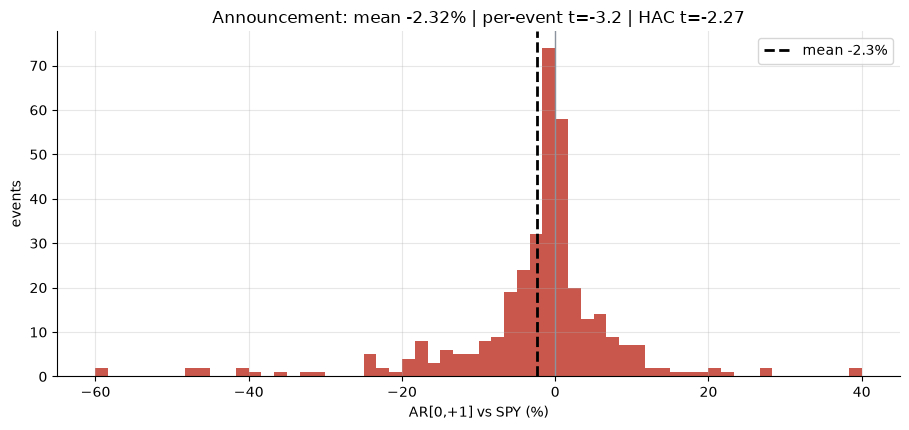

AR0 mean -2.32%  median -0.66%  t=-3.17  wins t=-4.55  HAC t=-2.27


In [2]:
if HAVE_REAL:
    s = st.summarize(TAB)
    ar0 = TAB['ar0'].to_numpy()*100
else:
    s = dict(ar0_mean_pct=R['ar0_mean'], ar0_median_pct=R['ar0_median'],
             ar0_t=R['ar0_t'], ar0_t_wins=R['ar0_t_wins'], ar0_t_hac=R['ar0_t_hac'])
    ar0 = np.random.default_rng(631).normal(R['ar0_mean'], 12, R['n_usable'])
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.hist(np.clip(ar0, -60, 40), bins=60, color=RED, alpha=.85)
ax.axvline(np.mean(ar0), c='k', ls='--', lw=2, label=f'mean {np.mean(ar0):+.1f}%')
ax.axvline(0, c=GREY, lw=1)
ax.set_xlabel('AR[0,+1] vs SPY (%)'); ax.set_ylabel('events')
ax.set_title(f"Announcement: mean {s['ar0_mean_pct']:+.2f}% | per-event t={s['ar0_t']:+.1f} | HAC t={s['ar0_t_hac']:+.2f}")
ax.legend(); plt.tight_layout(); plt.show()
print(f"AR0 mean {s['ar0_mean_pct']:+.2f}%  median {s['ar0_median_pct']:+.2f}%  "
      f"t={s['ar0_t']:+.2f}  wins t={s['ar0_t_wins']:+.2f}  HAC t={s['ar0_t_hac']:+.2f}")

> 💡 In plain words: the confession costs **-2.3%** vs the market in two days (median -0.7% — most 4.02s are technical; a minority are catastrophic). Winsorized t = **-4.55**, month-clustered HAC t = **-2.27** — H₁ **certified**. This half of the claim is just market efficiency working.

### 4b · The raw drift — loud, robust… and not yet an answer

Horizon curve plus the headline 63-day window, with winsorized and penny-floor variants. Everything here passes; the question it *cannot* answer is attribution.

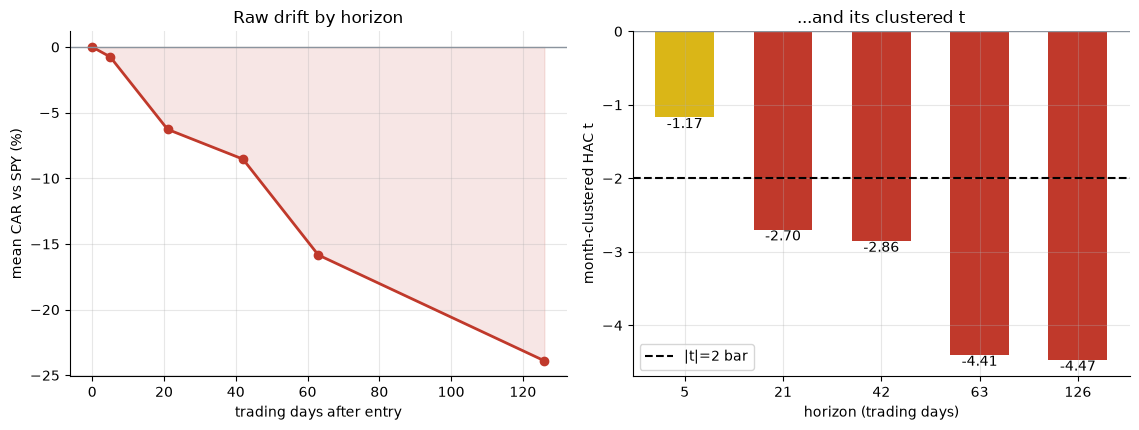

63d: CAR -15.84% (median -5.86%)  t=-4.01  wins t=-5.06  HAC t=-4.41
entry >= $1: n=289  CAR -13.41%  t=-4.79  HAC t=-4.20
entry >= $5: n=228  CAR -12.97%  t=-4.05  HAC t=-3.54


In [3]:
if HAVE_REAL:
    s = st.summarize(TAB)
    hz = st.horizon_curve(EV, CLOSE, DVOL, SPY)
    H = list(zip(hz['days'], hz['n'], hz['car_pct'], hz['t'], hz['t_hac']))
    FL = []
    for f in (1.0, 5.0):
        sub = TAB[TAB['p_in'] >= f]
        FL.append((f, len(sub), sub['car'].mean()*100,
                   st.ttest_vs_zero(sub['car'].to_numpy()),
                   st.clustered_hac_t(sub)['t_hac']))
    core = (s['car_mean_pct'], s['car_median_pct'], s['car_t'], s['car_t_wins'], s['car_t_hac'])
else:
    H = R['horizon']; FL = R['floors']
    core = (R['car_mean'], R['car_median'], R['car_t'], R['car_t_wins'], R['car_t_hac'])
days = [h[0] for h in H]; cars = [h[2] for h in H]; thac = [h[4] for h in H]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4))
a1.plot([0]+days, [0]+cars, marker='o', color=RED, lw=2)
a1.axhline(0, c=GREY, lw=1); a1.fill_between([0]+days, [0]+cars, 0, color=RED, alpha=.12)
a1.set_xlabel('trading days after entry'); a1.set_ylabel('mean CAR vs SPY (%)')
a1.set_title('Raw drift by horizon')
a2.bar([str(int(d)) for d in days], thac, color=[AMBER if abs(t)<2 else RED for t in thac], width=.6)
a2.axhline(-2, ls='--', c='k', label='|t|=2 bar'); a2.axhline(0, c=GREY, lw=1)
for i,t in enumerate(thac): a2.annotate(f'{t:+.2f}',(i,t),ha='center',va='top' if t<0 else 'bottom')
a2.set_xlabel('horizon (trading days)'); a2.set_ylabel('month-clustered HAC t')
a2.set_title('...and its clustered t'); a2.legend()
plt.tight_layout(); plt.show()
print(f'63d: CAR {core[0]:+.2f}% (median {core[1]:+.2f}%)  t={core[2]:+.2f}  '
      f'wins t={core[3]:+.2f}  HAC t={core[4]:+.2f}')
for f in FL: print(f'entry >= ${f[0]:.0f}: n={int(f[1])}  CAR {f[2]:+.2f}%  t={f[3]:+.2f}  HAC t={f[4]:+.2f}')

> 💡 In plain words: the raw 3-month drift is **-15.84%** with a month-clustered HAC t of **-4.41** — it clears the bar, survives winsorization (-5.06), penny floors (≥$5: -12.97%, HAC -3.54) and grows with horizon. A naive study stops here and stamps REAL. The next cell is why we don't.

### 4c · The chronic-decay placebo — the verdict-maker

H₂′: same stock, same 63-day window length, entered **252 trading days before** the event. If the "drift" is the event's doing, the placebo should be ≈ 0 and the paired difference should carry the whole effect.

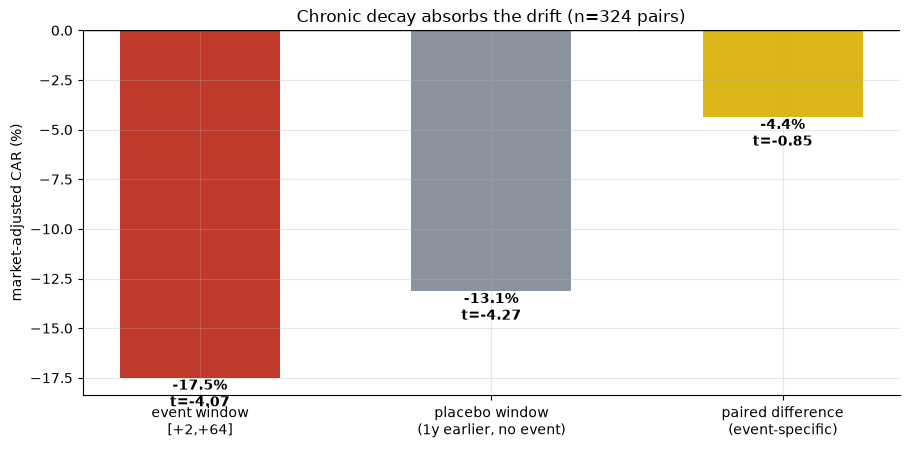

event -17.49% (t=-4.07) | placebo -13.13% (t=-4.27) | diff -4.36% (t=-0.85, wins -0.93, HAC -0.63)


In [4]:
if HAVE_REAL:
    pl = st.chronic_decay_placebo(EV, CLOSE, DVOL, SPY)
else:
    pl = dict(n_pairs=R['n_pairs'], event_pct=R['plc_event'], event_t=R['plc_event_t'],
              placebo_pct=R['plc_plc'], placebo_t=R['plc_plc_t'], diff_pct=R['diff'],
              diff_t=R['diff_t'], diff_t_wins=R['diff_t_wins'], diff_t_hac=R['diff_t_hac'])
fig, ax = plt.subplots(figsize=(9.2, 4.6))
labs = ['event window\n[+2,+64]', 'placebo window\n(1y earlier, no event)',
        'paired difference\n(event-specific)']
vals = [pl['event_pct'], pl['placebo_pct'], pl['diff_pct']]
ts   = [pl['event_t'], pl['placebo_t'], pl['diff_t']]
ax.bar(labs, vals, color=[RED, GREY, AMBER], width=.55)
for i,(v,t) in enumerate(zip(vals,ts)):
    ax.annotate(f'{v:+.1f}%\nt={t:+.2f}', (i, v), ha='center', va='top', fontweight='bold')
ax.axhline(0, c='k', lw=1); ax.set_ylabel('market-adjusted CAR (%)')
ax.set_title(f'Chronic decay absorbs the drift (n={pl["n_pairs"]} pairs)')
plt.tight_layout(); plt.show()
print(f"event {pl['event_pct']:+.2f}% (t={pl['event_t']:+.2f}) | placebo "
      f"{pl['placebo_pct']:+.2f}% (t={pl['placebo_t']:+.2f}) | diff {pl['diff_pct']:+.2f}% "
      f"(t={pl['diff_t']:+.2f}, wins {pl['diff_t_wins']:+.2f}, HAC {pl['diff_t_hac']:+.2f})")

> 💡 In plain words: the placebo windows — no confession anywhere near them — bleed **-13.13%** (t = -4.27), almost as much as the event windows (-17.49%). The event-specific increment is **-4.36%** at paired t = **-0.85** (winsorized -0.93, HAC -0.63). Right sign, nowhere near the bar. **H₂′ fails** — the drift is composition (melting ice cubes), not underreaction. This single test flips the study's verdict from REAL to MIXED.

### 4d · Era split — where the survivor-mapping bias shows its face

The CIK→ticker map is current: a 2005 filer still mapped today is a 20-year survivor, so the early era keeps only its *winners*.

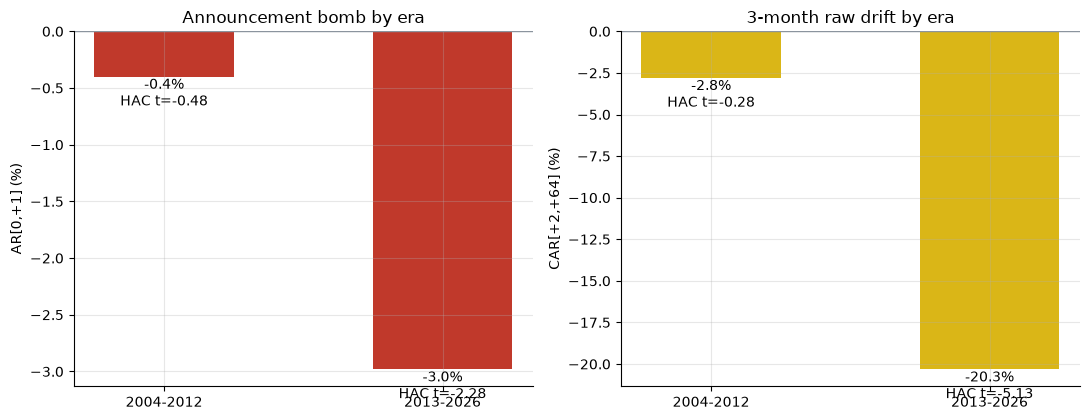

2004-2012: n=92  ann -0.40% (HAC t=-0.48)  drift -2.81% (t=-0.64, HAC t=-0.28)
2013-2026: n=267  ann -2.98% (HAC t=-2.28)  drift -20.33% (t=-4.02, HAC t=-5.13)


In [5]:
if HAVE_REAL:
    E = []
    for lab, m in (('2004-2012', TAB['date'] <= '2012-12-31'),
                   ('2013-2026', TAB['date'] > '2012-12-31')):
        se = st.summarize(TAB[m])
        E.append((lab, se['n_events'], se['ar0_mean_pct'], se['ar0_t_hac'],
                  se['car_mean_pct'], se['car_t'], se['car_t_hac']))
else:
    E = R['era']
labs = [e[0] for e in E]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(labs, [e[2] for e in E], color=RED, width=.5)
for i,e in enumerate(E): a1.annotate(f'{e[2]:+.1f}%\nHAC t={e[3]:+.2f}',(i,e[2]),ha='center',va='top')
a1.set_title('Announcement bomb by era'); a1.set_ylabel('AR[0,+1] (%)')
a2.bar(labs, [e[4] for e in E], color=AMBER, width=.5)
for i,e in enumerate(E): a2.annotate(f'{e[4]:+.1f}%\nHAC t={e[6]:+.2f}',(i,e[4]),ha='center',
    va='top' if e[4]<0 else 'bottom')
a2.set_title('3-month raw drift by era'); a2.set_ylabel('CAR[+2,+64] (%)')
for a in (a1,a2): a.axhline(0, c=GREY, lw=1)
plt.tight_layout(); plt.show()
for e in E: print(f'{e[0]}: n={e[1]}  ann {e[2]:+.2f}% (HAC t={e[3]:+.2f})  drift {e[4]:+.2f}% (t={e[5]:+.2f}, HAC t={e[6]:+.2f})')

> 💡 In plain words: the early era is flat (drift -2.8%, HAC t = -0.28) — exactly where only 20-year survivors remain on the tape — and the modern era carries everything (-20.3%, HAC t = -5.13, SPAC-era microcaps). Consistent with the named mapping bias plus chronic decay; inconsistent with a stable underreaction premium.

### 4e · Third axis — limits to arbitrage: is it a small-cap story?

Median split on pre-event median **dollar volume** ([−65,−6]; only the cross-sectional order is used). Shleifer-Vishny: mispricing persists where arbitrage capital won't go.

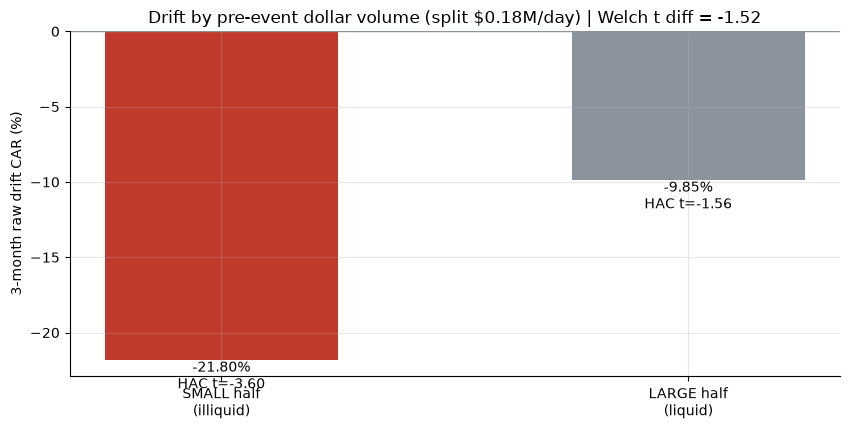

small: n=180 CAR -21.80% t=-3.32 HAC -3.60 | large: n=179 CAR -9.85% t=-2.27 HAC -1.56 | Welch diff -1.52


In [6]:
if HAVE_REAL:
    sp = st.size_split(TAB)
    sm = (sp['n_small'], sp['small_car_pct'], sp['small_t'], sp['small_t_hac'])
    lg = (sp['n_large'], sp['large_car_pct'], sp['large_t'], sp['large_t_hac'])
    wd = sp['welch_t_diff']; med = sp['median_dvol_musd']
else:
    sm, lg, wd, med = R['small'], R['large'], R['welch_diff'], R['split_musd']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['SMALL half\n(illiquid)','LARGE half\n(liquid)'], [sm[1], lg[1]],
       color=[RED, GREY], width=.5)
for i,(v,t) in enumerate([(sm[1],sm[3]),(lg[1],lg[3])]):
    ax.annotate(f'{v:+.2f}%\nHAC t={t:+.2f}',(i,v),ha='center',va='top' if v<0 else 'bottom')
ax.axhline(0, c=GREY, lw=1)
ax.set_ylabel('3-month raw drift CAR (%)')
ax.set_title(f'Drift by pre-event dollar volume (split ${med:.2f}M/day) | Welch t diff = {wd:+.2f}')
plt.tight_layout(); plt.show()
print(f'small: n={sm[0]} CAR {sm[1]:+.2f}% t={sm[2]:+.2f} HAC {sm[3]:+.2f} | '
      f'large: n={lg[0]} CAR {lg[1]:+.2f}% t={lg[2]:+.2f} HAC {lg[3]:+.2f} | Welch diff {wd:+.2f}')

> 💡 In plain words: **-21.80%** in the illiquid half vs **-9.85%** in the liquid half — the direction Shleifer-Vishny predicts — but Welch t = **-1.52**: not separable. And note the whole panel is microcap (the *median* split point is $0.18M/day); "large" here means *less tiny*. **MIXED** — and the placebo already showed the drift isn't event-specific in either half's favor.

### 4f · Tradability — the short pays its bills first

Short at close +1, cover at +64 (the market-adjusted CAR *is* the SPY-hedged P&L); one-way costs × 2 legs on the stock + 1 bp × 2 on SPY + borrow × 63/252.

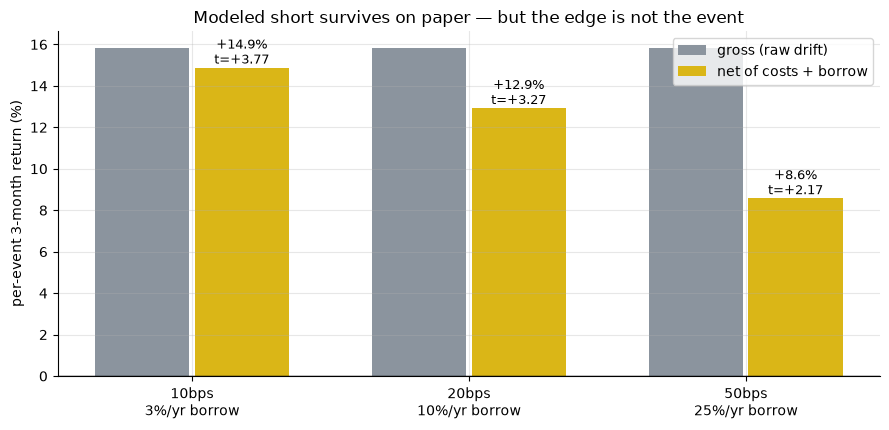

cost=10bps borrow=3%/yr: gross +15.84% drag 0.97% net +14.87%  t=+3.77  HAC t=+4.09
cost=20bps borrow=10%/yr: gross +15.84% drag 2.92% net +12.92%  t=+3.27  HAC t=+3.45
cost=50bps borrow=25%/yr: gross +15.84% drag 7.27% net +8.57%  t=+2.17  HAC t=+2.03


In [7]:
if HAVE_REAL:
    OV = []
    for cb, bw in ((10.0,3.0),(20.0,10.0),(50.0,25.0)):
        o = st.short_overlay(TAB, cost_bps=cb, borrow_ann_pct=bw)
        OV.append((cb, bw, o['gross_pct'], o['drag_pct'], o['net_pct'],
                   o['net_t'], o['net_t_hac']))
else:
    OV = R['overlay']
labels = [f'{int(o[0])}bps\n{int(o[1])}%/yr borrow' for o in OV]
x = np.arange(len(OV))
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-.18, [o[2] for o in OV], .34, color=GREY, label='gross (raw drift)')
ax.bar(x+.18, [o[4] for o in OV], .34, color=AMBER, label='net of costs + borrow')
for i,o in enumerate(OV): ax.annotate(f'{o[4]:+.1f}%\nt={o[5]:+.2f}',(i+.18,o[4]),
    ha='center', va='bottom', fontsize=9)
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('per-event 3-month return (%)')
ax.set_title('Modeled short survives on paper — but the edge is not the event')
ax.legend(); plt.tight_layout(); plt.show()
for o in OV: print(f'cost={o[0]:.0f}bps borrow={o[1]:.0f}%/yr: gross {o[2]:+.2f}% '
                   f'drag {o[3]:.2f}% net {o[4]:+.2f}%  t={o[5]:+.2f}  HAC t={o[6]:+.2f}')

> 💡 In plain words: the *model* says even punitive terms leave +8.57%/event. So why MIRAGE? Three reasons. **(1)** The edge is not the claimed one — the event adds -4.36% (t = -0.85); what you'd really be harvesting is generic melting-microcap exposure. **(2)** Access: median pre-event dollar volume is $0.18M/day, many names are sub-$1 with no locate at any fee — the modeled borrow grid is generous fiction for half the panel. **(3)** Capacity ≈ nil; a buy-in forces you out exactly when the melt accelerates. Paper edge, unclaimable — **MIRAGE**.

### 4g · Machinery control — three worlds where we know the truth

Null (nothing planted), TRUE underreaction (−8% planted post-event drift), and the melting-ice-cube confound (−40%/yr chronic bleed on event stocks, **zero** event effect). The pipeline must tell drift from decay. *(Machinery proof only — never market evidence.)*

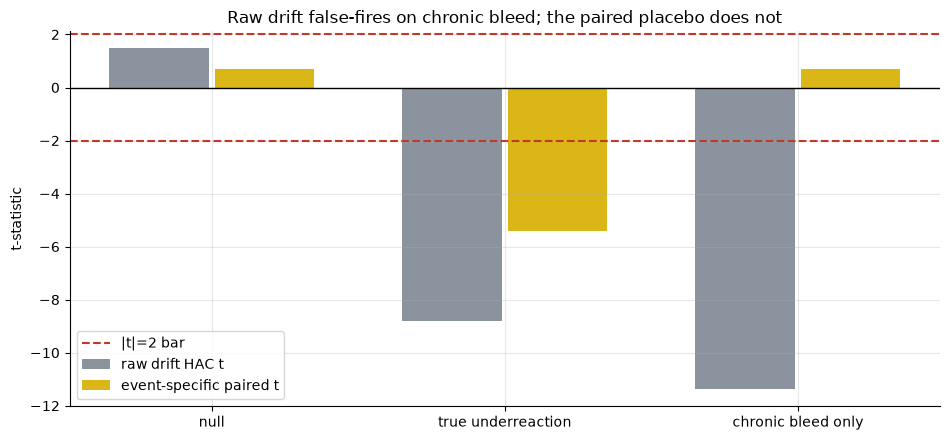

null                : raw +0.83% (HAC t=+1.48) | event-specific +0.92% (paired t=+0.71)
true underreaction  : raw -7.17% (HAC t=-8.80) | event-specific -7.08% (paired t=-5.42)
chronic bleed only  : raw -9.17% (HAC t=-11.37) | event-specific +0.92% (paired t=+0.71)


In [8]:
res = []
for lab, drift, chronic in (('null', 0.0, 0.0), ('true underreaction', -0.08, 0.0),
                            ('chronic bleed only', 0.0, -0.40)):
    ev_s, cl_s, dv_s, spy_s = data.synthetic_market(drift=drift, chronic=chronic, seed=631)
    tab_s = st.build_event_table(ev_s, cl_s, dv_s, spy_s)
    s_s = st.summarize(tab_s)
    pl_s = st.chronic_decay_placebo(ev_s, cl_s, dv_s, spy_s)
    res.append((lab, s_s['car_mean_pct'], s_s['car_t_hac'], pl_s['diff_pct'], pl_s['diff_t']))
x = np.arange(len(res))
fig, ax = plt.subplots(figsize=(9.6, 4.5))
ax.bar(x-.18, [r[2] for r in res], .34, color=GREY, label='raw drift HAC t')
ax.bar(x+.18, [r[4] for r in res], .34, color=AMBER, label='event-specific paired t')
ax.axhline(-2, ls='--', c=RED, label='|t|=2 bar'); ax.axhline(2, ls='--', c=RED)
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels([r[0] for r in res])
ax.set_ylabel('t-statistic')
ax.set_title('Raw drift false-fires on chronic bleed; the paired placebo does not')
ax.legend(); plt.tight_layout(); plt.show()
for r in res: print(f'{r[0]:<20}: raw {r[1]:+.2f}% (HAC t={r[2]:+.2f}) | '
                    f'event-specific {r[3]:+.2f}% (paired t={r[4]:+.2f})')

> 💡 In plain words: in the chronic-bleed world the raw detector screams (HAC t = -11.37) with **zero** true event effect — a false conviction — while the paired placebo stays quiet (t = +0.71); given a TRUE planted underreaction both fire (paired t = -5.42); in the null, neither. The machinery separates drift from decay — and the real tape matches the **chronic-bleed** world, not the underreaction one. *(Never cited as market evidence.)*

## 5 · The verdict

- **Signal `MIXED`** (split spelled out): **Real on the bomb** — AR[0,+1] = -2.32%, HAC t = -2.27, winsorized -4.55. **Not certified on the underreaction drift** — raw -15.84% (HAC t = -4.41) is real *bleeding*, but the event-specific part is -4.36% at paired t = -0.85: the confessing stocks bleed the same in no-event windows. **Deads-missing bias named**: the true damage is worse than this survivor-tilted tape can show, but a stamp needs the tape we have.
- **Tradability `MIRAGE`** — the modeled net (+12.92%/event at realistic terms) is chronic-decay exposure, not the event; unshortable sub-$0.18M/day scandal names; capacity ≈ nil.
- **Small-cap story? `MIXED`** — -21.80% (small) vs -9.85% (large), right direction, Welch t = -1.52 — not separable.

## 6 · Going further

- **Get the dead.** The one upgrade that could change the verdict: a survivorship-free tape (CRSP + delisting returns). The direction of the bias is *known* — it hides the bankrupt tail where a genuine event-specific drift could live.
- **Severity conditioning.** 4.02(a) vs 4.02(b) (management vs auditor), fraud language, restatement magnitude — Palmrose et al. find severity is *the* cross-sectional driver; the 2021 SPAC-warrant wave is a natural low-severity stratum.
- **Matched controls.** The placebo here is the stock's own past; a characteristics-matched control panel (same size/price/momentum, no 4.02) is the next rigor level — it also handles time-varying decay rates.
- **The pipeline view.** [229-beneish-m-score](../../229-beneish-m-score/) predicts the confession; this study shows the confession itself is priced in two days — so the alpha, if any, lives *before* the 8-K, not after it.

*Reproducible core offline & deterministic; one execution lag (close of day +1); shorts pay borrow. Sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*